## 单比特 $\sqrt{X}$ 门脉冲优化 


### 目录
1. [问题描述](###问题描述)
2. [解决方案](###解决方案)
3. [运行展示](###运行展示)
    - [基于高斯脉冲的优化](#基于高斯脉冲的优化)
    - [基于随机脉冲的优化](#基于随机脉冲的优化)
    - [脉冲鲁棒性](#脉冲鲁棒性)
    - [最佳脉冲](#最佳脉冲)
4. [经验总结](#经验总结)


### 问题描述



### 解决方案




### 运行展示

- 运行设备：Macmini M4
- 内存：16 GB


In [1]:
# 导入必备的库
import numpy as np
from multiprocessing import Pool, cpu_count
import time
import json

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="qutip")

import matplotlib.pyplot as plt
from matplotlib import rcParams
# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# 加载优化相关的函数
from spsa_solution import generate_initial_pulse, OpenSystemSPSA, evaluate_pulse
from spsa_solution import plot_pulses, plot_iter_hist, extract_scores_from_iter_hist
# 对原始评分器进行了优化，可以使用多进程并行计算
from single_transmon_grader import TransmonPulseGrader


首先，我们先设置初始评分器。注意，我们对官方的代码进行了修改，在 `TransmonPulseGrader` 类中添加了一个参数 `computing_method = 'parallel' or 'serial'`，用户可以选择多进程计算 6 个初始量子态在当前脉冲下的演化，再传入计算损失值，加快运行速度。在我们的 spsa 优化中，原始串行计算，完成一次迭代优化大约需要 50 秒，而多进程需 9 秒，提升 5 倍有余。

In [2]:
# 设置评分器
grader = TransmonPulseGrader(
    n_levels=4,
    n_steps=30,
    alpha=-2 * np.pi * 0.2e9,
    omega_q=2 * np.pi * 5.0e9,
    omega_d=2 * np.pi * 5.0e9,
    dt=5e-10,          # 0.5 ns
    T1=50e-6,
    T_phi=30e-6,
    n_bar=0.05,
    sigma_freq=0.5e6,  # 0.5 MHz
    n_shots=15,        # 默认评分shots
    h_a=179e6,
    h_d=22.4e6,
    A_penalty=0.1,
    computing_method='parallel' # 评分采用并行计算
)

# 相位
phi = 0.0
n_shots = 15
iters = 100 # 迭代次数

##### 基于高斯脉冲的优化

使用 `generate_initial_pulse` 函数生成一个高斯脉冲作为初始脉冲，其评分在 0.99 以上。往后查看最终的优化结果，我们可以发现优化后的 Ω_re 波形与初始一致，而 Ω_im 需要进行调整。

初始高斯脉冲的评分：0.9985


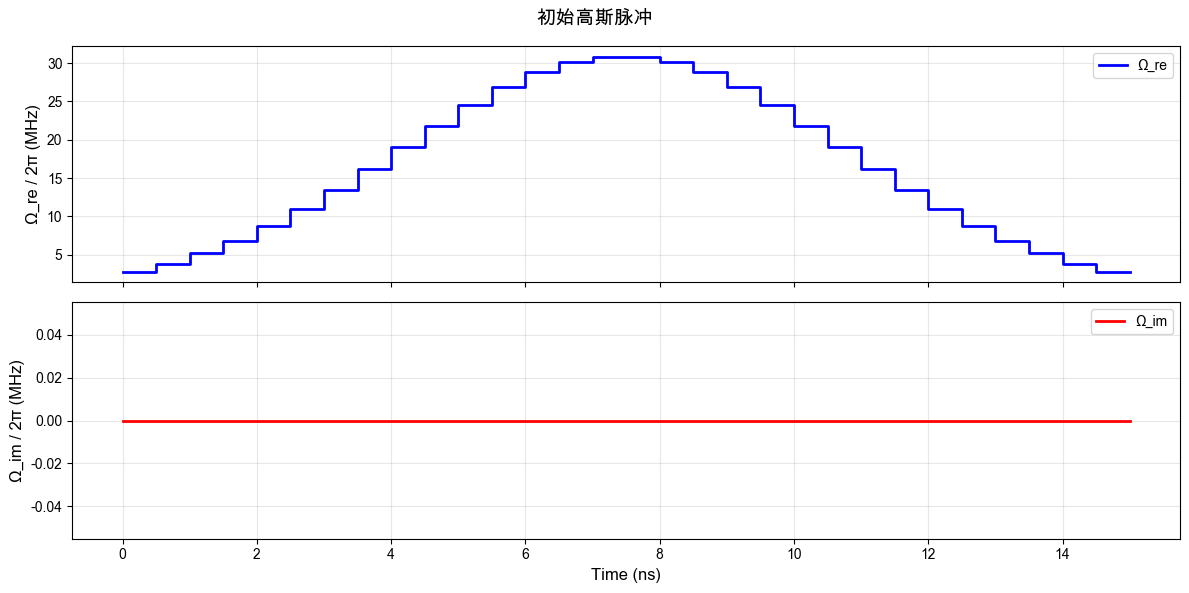

In [3]:
pulses_init_gaussian = generate_initial_pulse(grader.n_steps, grader.dt, method="gaussian", target_angle=np.pi/2)

plot_pulses(pulses_init_gaussian, grader.n_steps, grader.dt, title="初始高斯脉冲")

gaussian_score = grader.grade_submission(pulses_init_gaussian, phi, seed=42, n_shots=n_shots, verbose=False)['overall_score']
print(f"初始高斯脉冲的评分：{gaussian_score:.4f}")

使用 `OpenSystemSPSA` 类对高斯脉冲进行优化

In [4]:
# 定义优化器
optimizer = OpenSystemSPSA(
    grader=grader,
    n_steps=30,
    dt=5e-10,
    K=10,               # 10个结点 -> 30步插值
    Amax_MHz=179.0,     # 幅度上限 2π×179 MHz
    smooth_len=5,       # 轻度平滑窗口
    rng_seed=1234
)

time_start = time.time()
# 开始优化, 并获得过程中的迭代记录
pulses_best_gaussian, gaussian_iter_hist = optimizer.run(
    iters=iters,
    shots=n_shots,
    seeds=[42],
    pulses_init=pulses_init_gaussian,
    file_name="gaussian",
    verbose=True # 打印每次的迭代信息
)
time_end = time.time()
print(f"高斯脉冲优化耗时：{time_end - time_start:.4f} 秒")


计算初始分数
初始分数: 0.998498, 初始消耗时间: 2.42s
开始优化迭代
[SPSA] iter=1 score=0.998770 best=0.998770 ak=1.180e-02 ck=4.000e-02 iter_time=8.61s
[SPSA] iter=2 score=0.998777 best=0.998777 ak=1.120e-02 ck=3.730e-02 iter_time=8.21s
[SPSA] iter=3 score=0.998819 best=0.998819 ak=1.068e-02 ck=3.580e-02 iter_time=8.00s
[SPSA] iter=4 score=0.998858 best=0.998858 ak=1.021e-02 ck=3.477e-02 iter_time=7.86s
[SPSA] iter=5 score=0.998859 best=0.998859 ak=9.794e-03 ck=3.400e-02 iter_time=7.75s
[SPSA] iter=6 score=0.998860 best=0.998860 ak=9.421e-03 ck=3.338e-02 iter_time=8.45s
[SPSA] iter=7 score=0.998875 best=0.998875 ak=9.083e-03 ck=3.286e-02 iter_time=7.91s
[SPSA] iter=8 score=0.998928 best=0.998928 ak=8.776e-03 ck=3.242e-02 iter_time=8.02s
[SPSA] iter=9 score=0.998932 best=0.998932 ak=8.495e-03 ck=3.204e-02 iter_time=8.44s
[SPSA] iter=10 score=0.998947 best=0.998947 ak=8.237e-03 ck=3.170e-02 iter_time=8.39s
[SPSA] iter=11 score=0.999012 best=0.999012 ak=7.998e-03 ck=3.140e-02 iter_time=8.20s
[SPSA] iter=12 scor

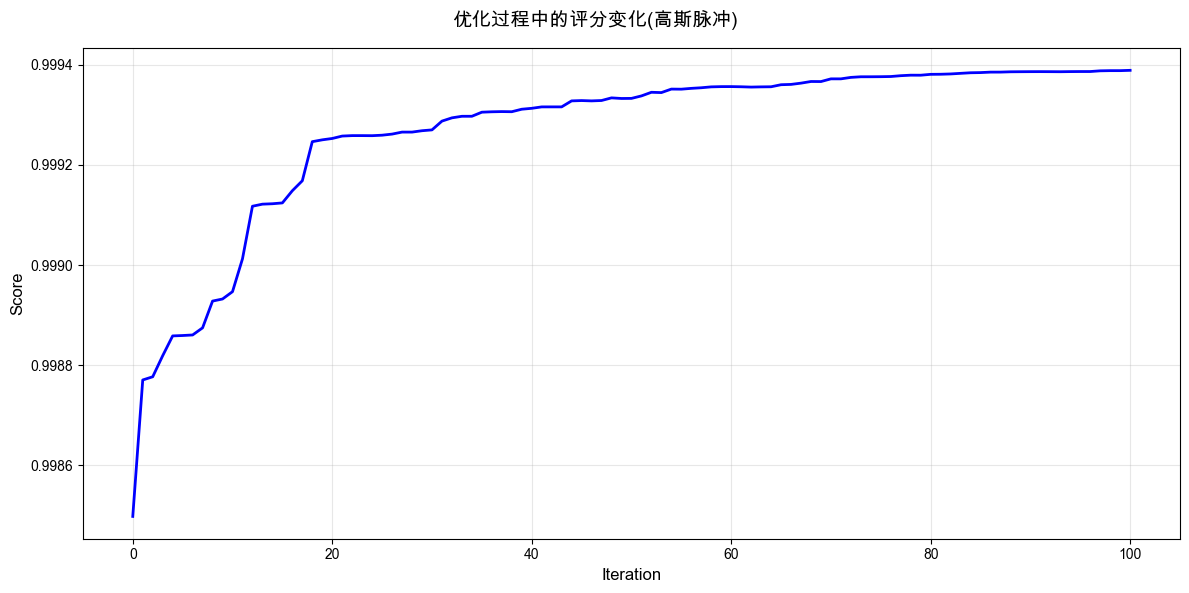

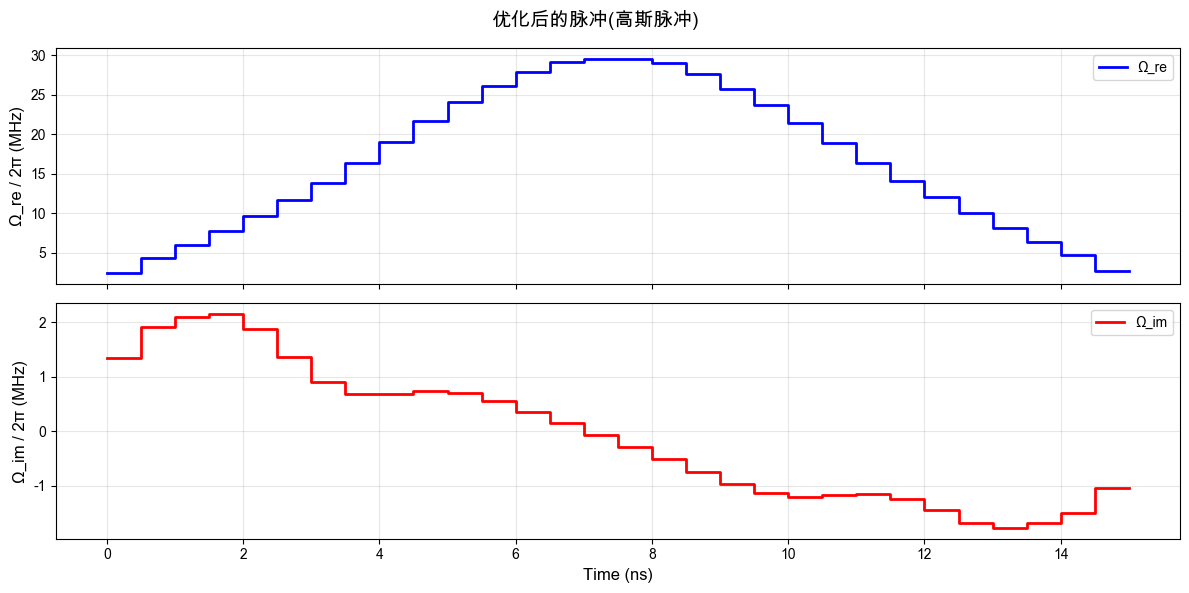

In [5]:
# 绘制迭代过程中的评分变化
plot_iter_hist(gaussian_iter_hist, title="优化过程中的评分变化(高斯脉冲)")
plot_pulses(pulses_best_gaussian, grader.n_steps, grader.dt, title="优化后的脉冲(高斯脉冲)")


Ω_re 波形与初始高斯脉冲一致，只需要微调 Ω_im 即可

##### 基于随机脉冲的优化

初始随机脉冲的评分：0.7331
计算初始分数
初始分数: 0.733122, 初始消耗时间: 1.01s
开始优化迭代
优化结束: best_score=0.989494
当前最优的脉冲: best_score=0.989494
已保存脉冲到 results/pulses_spsa_random.npy
已保存历史记录到 results/history_spsa_random.json
随机脉冲优化耗时：806.0618 秒


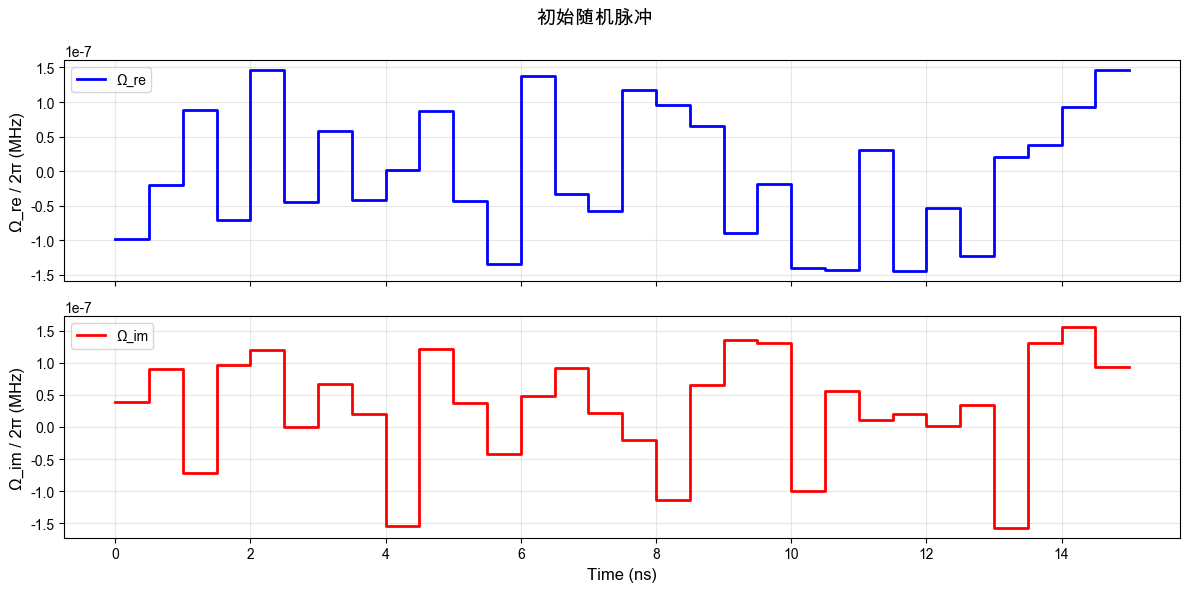

In [6]:
pulses_init_random = generate_initial_pulse(grader.n_steps, grader.dt, method="random", seed=1234)

plot_pulses(pulses_init_random, grader.n_steps, grader.dt, title="初始随机脉冲")

random_score = grader.grade_submission(pulses_init_random, phi, seed=42, n_shots=n_shots, verbose=False)['overall_score']
print(f"初始随机脉冲的评分：{random_score:.4f}")

time_start_random = time.time()
# 开始优化, 并获得过程中的迭代记录
pulses_best_random, random_iter_hist = optimizer.run(
    iters=iters,
    shots=n_shots,
    seeds=[42],
    pulses_init=pulses_init_random,
    file_name="random",
    verbose=False # 打印每次的迭代信息
)
time_end_random = time.time()
print(f"随机脉冲优化耗时：{time_end_random - time_start_random:.4f} 秒")


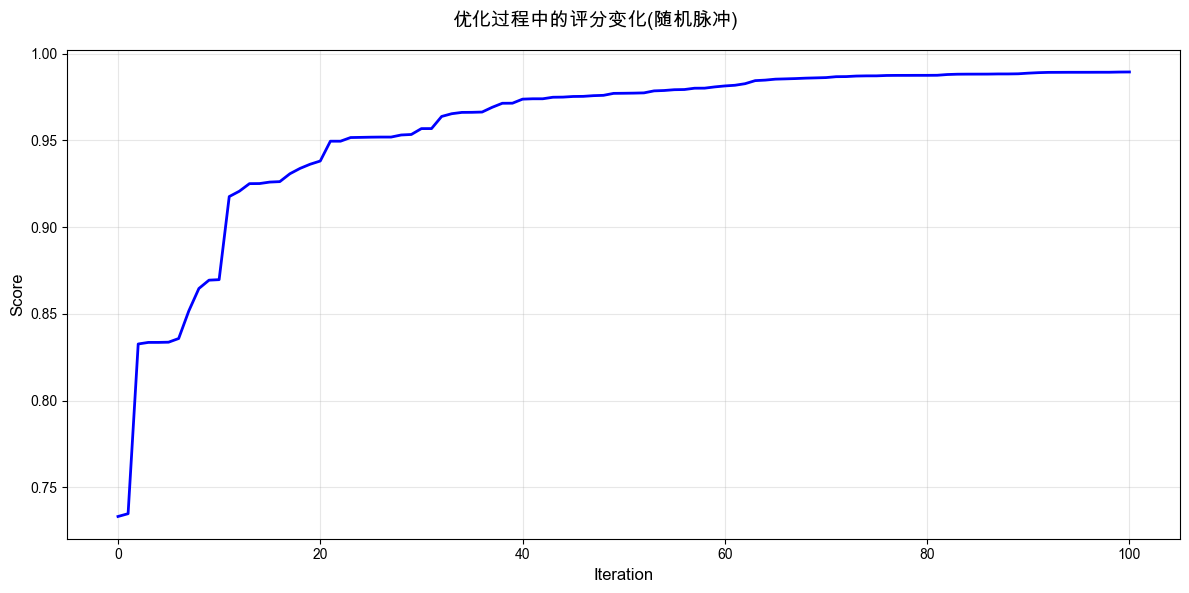

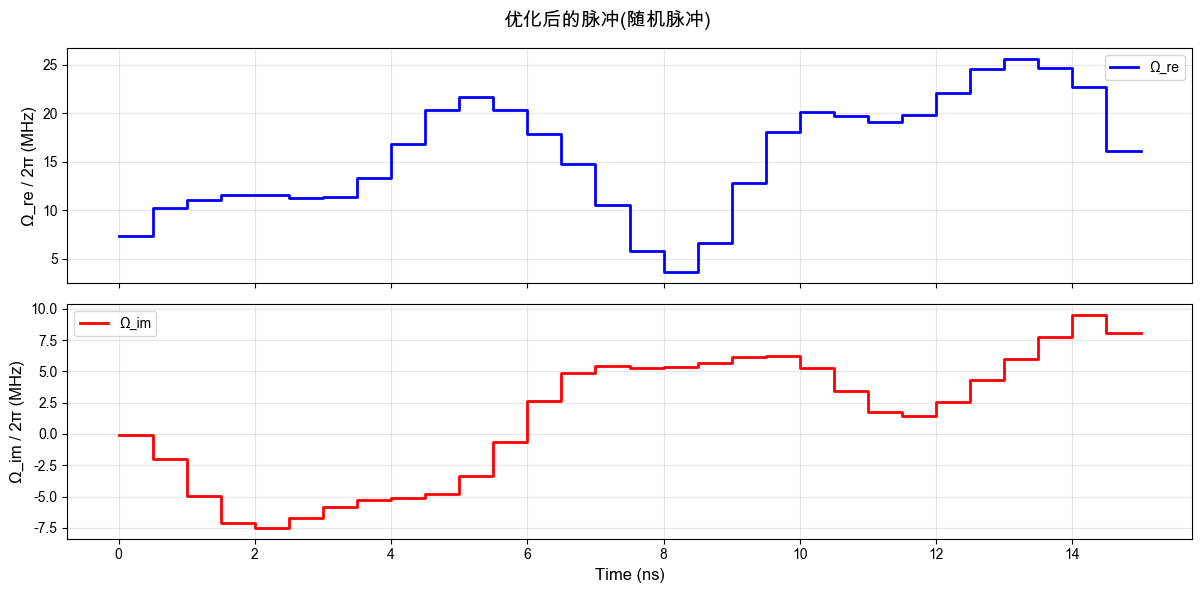

In [7]:
# 绘制迭代过程中的评分变化
plot_iter_hist(random_iter_hist, title="优化过程中的评分变化(随机脉冲)")
# 绘制优化后的脉冲
plot_pulses(pulses_best_random, grader.n_steps, grader.dt, title="优化后的脉冲(随机脉冲)")

##### 脉冲鲁棒性

使用基于高斯脉冲和随机脉冲，优化得到的最终脉冲，基于随机的评分器种子数 seed（影响噪声的作用），随机运行100次 `grader.grade_submission`，统计平均评分、门错误、门保真度、泄漏和惩罚，查看脉冲针对不同噪声影响下的鲁棒性。


In [8]:
# 准备并行计算参数
iters_num = 100
args_list_gaussian = [(pulses_best_gaussian, phi, n_shots) for _ in range(iters_num)]
args_list_random = [(pulses_best_random, phi, n_shots) for _ in range(iters_num)]

# 使用多进程并行计算
start_time = time.time()
with Pool() as pool:
    # 并行计算两组脉冲的评分
    # evaluate_pulse 中评分器是串行计算
    results_gaussian = pool.map(evaluate_pulse, args_list_gaussian)
    results_random = pool.map(evaluate_pulse, args_list_random)
end_time = time.time()
print(f"并行计算耗时: {end_time - start_time:.2f} 秒")


并行计算耗时: 608.44 秒


In [9]:
# 提取结果
score_list_gaussian = [r[0] for r in results_gaussian]
gate_error_list_gaussian = [r[1] for r in results_gaussian]
gate_fidelity_list_gaussian = [r[2] for r in results_gaussian]
leakage_list_gaussian = [r[3] for r in results_gaussian]
penalty_list_gaussian = [r[4] for r in results_gaussian]

score_list_random = [r[0] for r in results_random]
gate_error_list_random = [r[1] for r in results_random]
gate_fidelity_list_random = [r[2] for r in results_random]
leakage_list_random = [r[3] for r in results_random]
penalty_list_random = [r[4] for r in results_random]

# 打印统计信息
print("\n=== pulses_spsa_gaussian 统计信息 ===")
print(f"平均评分: {np.mean(score_list_gaussian):.6f} ± {np.std(score_list_gaussian):.6f} max: {np.max(score_list_gaussian):.6f}, min: {np.min(score_list_gaussian):.6f}")
print(f"门错误: {np.mean(gate_error_list_gaussian):.6f} ± {np.std(gate_error_list_gaussian):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_gaussian):.6f} ± {np.std(gate_fidelity_list_gaussian):.6f}")
print(f"泄漏: {np.mean(leakage_list_gaussian):.6f} ± {np.std(leakage_list_gaussian):.6f}")
print(f"惩罚: {np.mean(penalty_list_gaussian):.6f} ± {np.std(penalty_list_gaussian):.6f}")

print("\n=== pulses_spsa_random 统计信息 ===")
print(f"平均评分: {np.mean(score_list_random):.6f} ± {np.std(score_list_random):.6f} max: {np.max(score_list_random):.6f}, min: {np.min(score_list_random):.6f}")
print(f"门错误: {np.mean(gate_error_list_random):.6f} ± {np.std(gate_error_list_random):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_random):.6f} ± {np.std(gate_fidelity_list_random):.6f}")
print(f"泄漏: {np.mean(leakage_list_random):.6f} ± {np.std(leakage_list_random):.6f}")
print(f"惩罚: {np.mean(penalty_list_random):.6f} ± {np.std(penalty_list_random):.6f}")




=== pulses_spsa_gaussian 统计信息 ===
平均评分: 0.999368 ± 0.000038 max: 0.999451, min: 0.999252
门错误: 0.000608 ± 0.000047
门保真度: 0.999392 ± 0.000047
泄漏: 0.999663 ± 0.000002
惩罚: 0.998107 ± 0.000000

=== pulses_spsa_random 统计信息 ===
平均评分: 0.987592 ± 0.000333 max: 0.988559, min: 0.986569
门错误: 0.013971 ± 0.000415
门保真度: 0.986029 ± 0.000415
泄漏: 0.992820 ± 0.000047
惩罚: 0.996914 ± 0.000000


##### 最佳脉冲

从前面两小节，我们可以看到使用高斯脉冲 + spsa 优化得到的最终脉冲，在不同噪声下的鲁棒性更好，得分更高，且更容易优化。因此，我们选择该方案运行更多的迭代次数，以此得到最佳的脉冲，目前 `results` 中的 `pulses_best.npy`、`history_best.json` 是运行 4000 次迭代中得到的最终结果，大约需要 9 小时左右，在这里我们不选择运行了，而是直接导入这两个结果来进行分析，感兴趣的朋友可以直接取消注释来直接运行。

该脉冲整个 spsa 优化过程中，最佳得分为 0.9995232040672231，单比特门得分达到 0.999 以上。后续，我们运行 100 次不同 seed 下的官方评分器`grader.grade_submission`，平均得分为 0.999486，最高分数为 0.999527，最低分数为 0.999441，鲁棒性较好。


In [10]:
# pulses_best, iter_hist_best = optimizer.run(
#     iters=4000,
#     shots=n_shots,
#     seeds=[42],
#     pulses_init=pulses_init_gaussian,
#     file_name="gaussian_best",
#     verbose=False # 打印每次的迭代信息
# )

最高分数： 0.9995232040672231


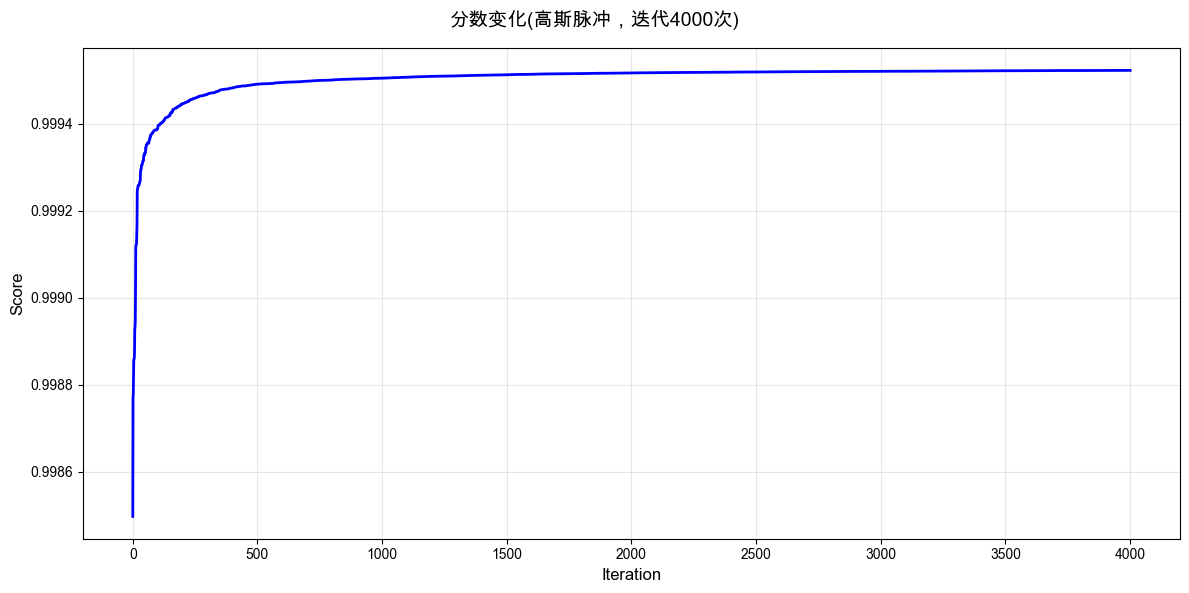

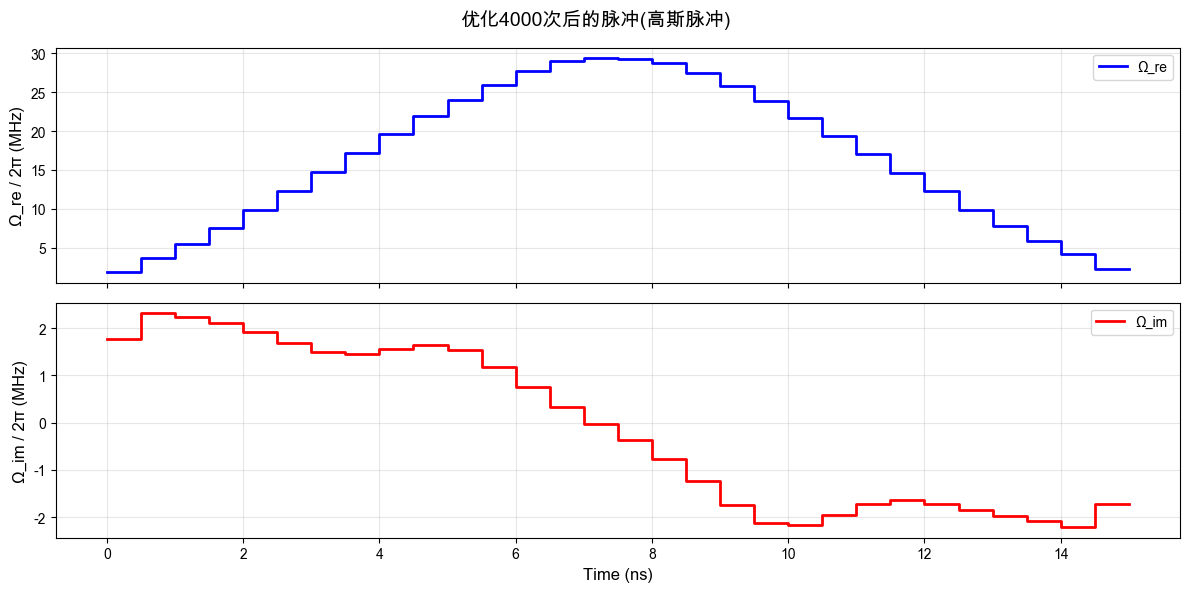

In [11]:
# 最终优化得到的脉冲
pulses_best = np.load("results/pulses_best.npy")

# 加载JSON文件
with open("results/history_best.json", 'r') as f:
    iter_hist_best = json.load(f)

# 绘制迭代过程中的评分变化
plot_iter_hist(iter_hist_best, title="分数变化(高斯脉冲，迭代4000次)")
# 绘制优化后的脉冲
plot_pulses(pulses_best, grader.n_steps, grader.dt, title="优化4000次后的脉冲(高斯脉冲)")

scores_list = extract_scores_from_iter_hist(iter_hist_best)
print("最高分数：", np.max(scores_list))


In [12]:

# 运行 100 次随机的评分，查看鲁棒性
args_list_best = [(pulses_best, phi, n_shots) for _ in range(100)]

# 使用多进程并行计算
start_time = time.time()
with Pool() as pool:
    results_best = pool.map(evaluate_pulse, args_list_best)
end_time = time.time()
print(f"并行计算耗时: {end_time - start_time:.2f} 秒")


并行计算耗时: 284.08 秒


In [13]:

score_list_best = [r[0] for r in results_best]
gate_error_list_best = [r[1] for r in results_best]
gate_fidelity_list_best = [r[2] for r in results_best]
leakage_list_best = [r[3] for r in results_best]
penalty_list_best = [r[4] for r in results_best]

# 打印统计信息
print("\n=== 最佳脉冲统计信息 ===")
print(f"平均评分: {np.mean(score_list_best):.6f} ± {np.std(score_list_best):.6f} max: {np.max(score_list_best):.6f}, min: {np.min(score_list_best):.6f}")
print(f"门错误: {np.mean(gate_error_list_best):.6f} ± {np.std(gate_error_list_best):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_best):.6f} ± {np.std(gate_fidelity_list_best):.6f}")
print(f"泄漏: {np.mean(leakage_list_best):.6f} ± {np.std(leakage_list_best):.6f}")
print(f"惩罚: {np.mean(penalty_list_best):.6f} ± {np.std(penalty_list_best):.6f}")



=== 最佳脉冲统计信息 ===
平均评分: 0.999490 ± 0.000032 max: 0.999585, min: 0.999384
门错误: 0.000500 ± 0.000039
门保真度: 0.999500 ± 0.000039
泄漏: 0.999910 ± 0.000000
惩罚: 0.998076 ± 0.000000


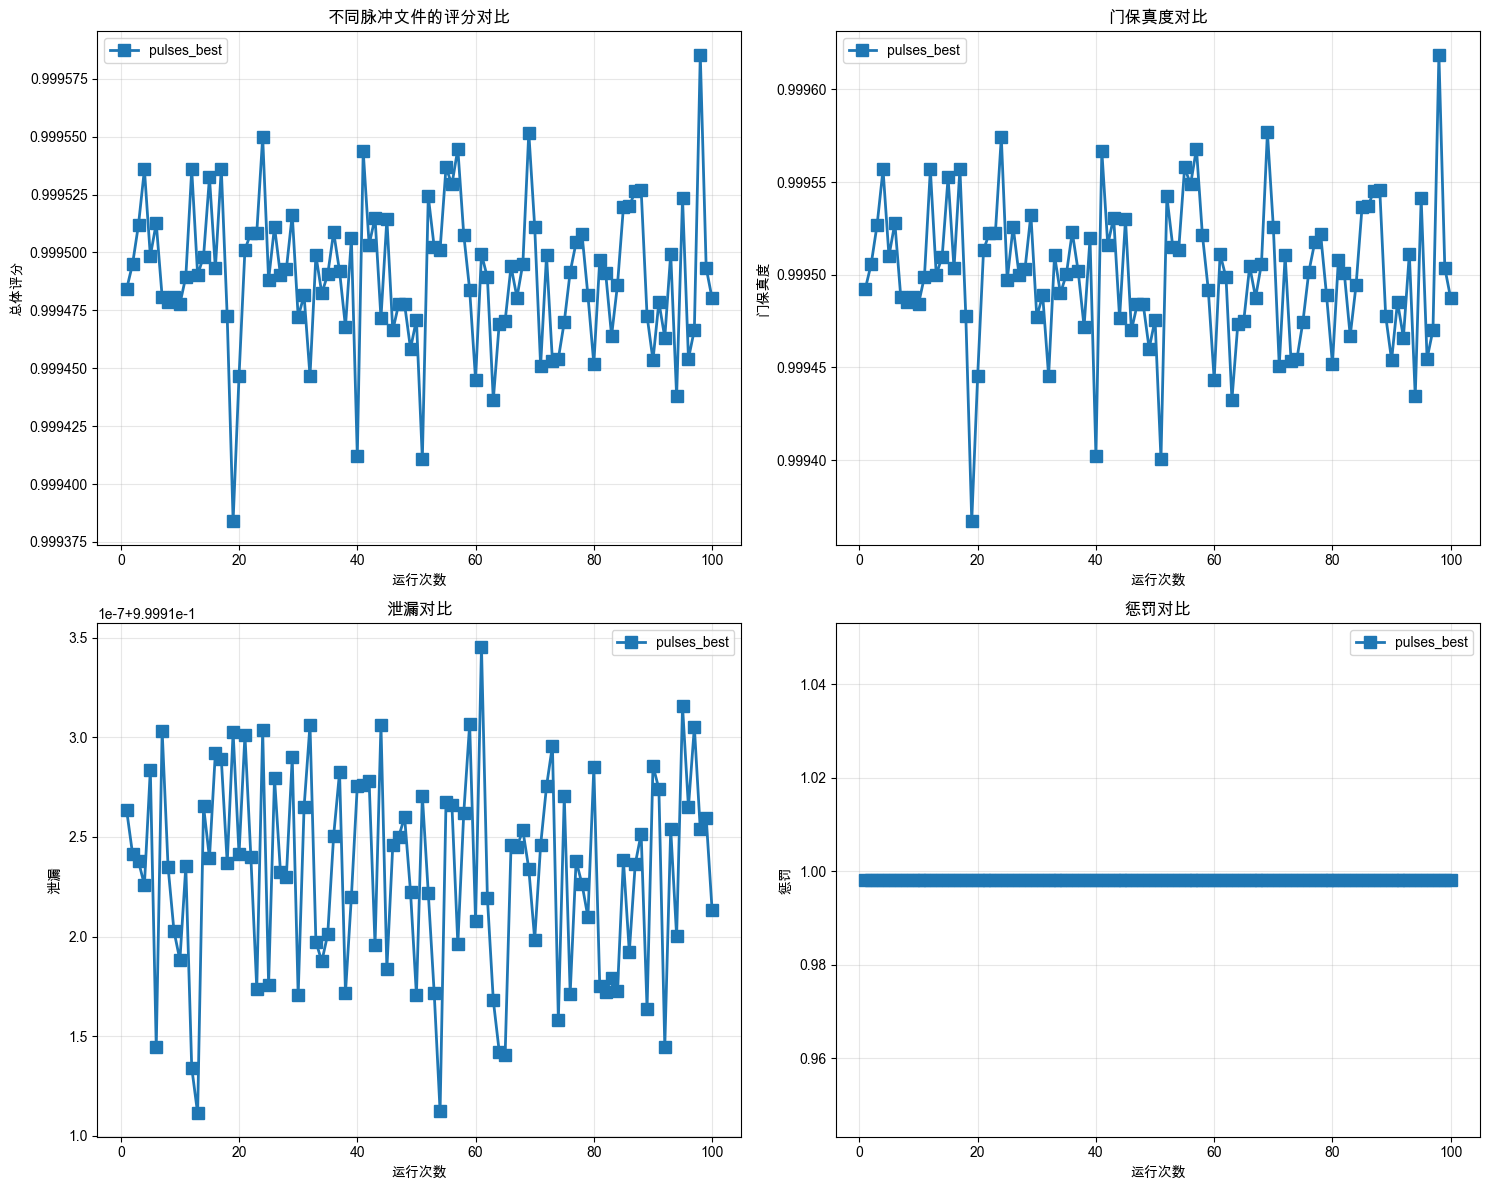

In [14]:
# 绘制详细结果
plt.figure(figsize=(15, 12))

# 子图1: 评分对比
plt.subplot(2, 2, 1)
plt.plot(range(1, iters_num+1), score_list_best, 's-', label='pulses_best', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('总体评分')
plt.title('不同脉冲文件的评分对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 门保真度对比
plt.subplot(2, 2, 2)
plt.plot(range(1, iters_num+1), gate_fidelity_list_best, 's-', label='pulses_best', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('门保真度')
plt.title('门保真度对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 泄漏对比
plt.subplot(2, 2, 3)
plt.plot(range(1, iters_num+1), leakage_list_best, 's-', label='pulses_best', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('泄漏')
plt.title('泄漏对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4: 惩罚对比
plt.subplot(2, 2, 4)
plt.plot(range(1, iters_num+1), penalty_list_best, 's-', label='pulses_best', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('惩罚')
plt.title('惩罚对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 经验总结

- 好的初始脉冲，对我们的优化事半功倍。